#### Analysis Goal
Generating reliable production expectations and risk bands for investment planning by removing the 2015–2023 monthly and annual solar irradiance patterns from PVGIS data for Turkiye.

## Problem Definition (Business Understanding)

### Business Objective
The purpose of this project is to help energy companies and energy investors make faster, more accurate decisions in solar power plant (SPP) investments. Specifically, the goal is to provide data-driven prioritization for selecting investment provinces and regions across Turkiye.

### Who Will Use This Project?
- Energy companies (business development and project development teams)
- Energy investors
- Financial evaluation and feasibility teams

### Which Decision Will It Improve?
- Location selection for solar power plant investments
- Prioritization of candidate investment regions
- Early elimination of low-potential locations during the pre-feasibility stage

### Problem Statement
SPP investment decisions are often made using fragmented data sources and manual evaluations. As a result, consistently identifying regions with high production potential becomes difficult. This increases the risk of incorrect location selection and leads to time and cost losses.

### Success Criteria
In this project, **MAPE (Mean Absolute Percentage Error)** is used as the primary success metric.

- **Main metric:** MAPE
- **Why MAPE?**
  - It is easy for business units to interpret because it provides percentage-based error.
  - It makes comparisons between provinces and regions with different scales easier.
  - It directly shows how much predictions deviate in investment decision contexts.

### Constraints and Assumptions
- The accuracy and timeliness of the data sources used (e.g., PVGIS) are assumed to be valid.
- The analysis is intended for pre-feasibility decision support; detailed site surveys and grid connection analyses are out of scope.
- Meteorological uncertainties and local site conditions may affect final investment decisions.

### Expected Output
- Comparative analysis of SPP investment suitability across Turkiye
- Ranking of locations according to production potential
- A measurable and repeatable evaluation approach that supports investment decisions

In [6]:
import json
from pathlib import Path

import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Project root not found from cwd={cwd}. Expected to locate 'data/raw/pvgis'."
    )

json_path = project_root / "data" / "raw" / "pvgis" / "turkey_provinces_81_seriescalc_2015_2026.json"

with json_path.open("r", encoding="utf-8") as f:
    raw = json.load(f)

rows = []
for province_obj in raw.get("provinces", []):
    plate_code = province_obj.get("plate_code")
    province = province_obj.get("province")
    latitude = province_obj.get("latitude")
    longitude = province_obj.get("longitude")
    source = province_obj.get("source")

    for m in province_obj.get("monthly_series", []):
        rows.append(
            {
                "plate_code": plate_code,
                "province": province,
                "latitude": latitude,
                "longitude": longitude,
                "source": source,
                "year": m.get("year"),
                "month": m.get("month"),
                "avg_ghi_w_m2": m.get("avg_ghi_w_m2"),
                "hour_count": m.get("hour_count"),
            }
        )

df_raw = pd.DataFrame(
    rows,
    columns=[
        "plate_code",
        "province",
        "latitude",
        "longitude",
        "source",
        "year",
        "month",
        "avg_ghi_w_m2",
        "hour_count",
    ],
)

expected_rows = 81 * 9 * 12
actual_rows = len(df_raw)

print(f"Working dir   : {cwd}")
print(f"Project root  : {project_root}")
print(f"Source file   : {json_path}")
print(f"Expected rows : {expected_rows}")
print(f"Actual rows   : {actual_rows}")

if actual_rows != expected_rows:
    raise ValueError(
        f"Row count mismatch! Expected={expected_rows}, Actual={actual_rows}"
    )

df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
df_raw["month"] = pd.to_numeric(df_raw["month"], errors="coerce").astype("Int64")
df_raw["avg_ghi_w_m2"] = pd.to_numeric(df_raw["avg_ghi_w_m2"], errors="coerce")
df_raw["hour_count"] = pd.to_numeric(df_raw["hour_count"], errors="coerce").astype("Int64")

df_raw = df_raw.sort_values(["plate_code", "year", "month"]).reset_index(drop=True)

print("\nDataFrame shape:", df_raw.shape)
df_raw.head()

Working dir   : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/analysis/notebooks
Project root  : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai
Source file   : /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/raw/pvgis/turkey_provinces_81_seriescalc_2015_2026.json
Expected rows : 8748
Actual rows   : 8748

DataFrame shape: (8748, 9)


,plate_code,province,latitude,longitude,source,year,month,avg_ghi_w_m2,hour_count
0,1,Adana,37.001667,35.328889,PVGIS,2015,1,98.4119,744
1,1,Adana,37.001667,35.328889,PVGIS,2015,2,116.8229,672
2,1,Adana,37.001667,35.328889,PVGIS,2015,3,186.1610,744
3,1,Adana,37.001667,35.328889,PVGIS,2015,4,226.4525,720
4,1,Adana,37.001667,35.328889,PVGIS,2015,5,280.6265,744


In [8]:
import json
from pathlib import Path

import pandas as pd

try:
    df_raw
except NameError:
    cwd = Path.cwd().resolve()
    project_root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            f"Project root not found from cwd={cwd}. Expected to locate 'data/raw/pvgis'."
        )
    json_path = (
        project_root
        / "data"
        / "raw"
        / "pvgis"
        / "turkey_provinces_81_seriescalc_2015_2026.json"
    )
    with json_path.open("r", encoding="utf-8") as f:
        raw = json.load(f)
    rows = []
    for province_obj in raw.get("provinces", []):
        plate_code = province_obj.get("plate_code")
        province = province_obj.get("province")
        latitude = province_obj.get("latitude")
        longitude = province_obj.get("longitude")
        source = province_obj.get("source")
        for m in province_obj.get("monthly_series", []):
            rows.append(
                {
                    "plate_code": plate_code,
                    "province": province,
                    "latitude": latitude,
                    "longitude": longitude,
                    "source": source,
                    "year": m.get("year"),
                    "month": m.get("month"),
                    "avg_ghi_w_m2": m.get("avg_ghi_w_m2"),
                    "hour_count": m.get("hour_count"),
                }
            )
    df_raw = pd.DataFrame(
        rows,
        columns=[
            "plate_code",
            "province",
            "latitude",
            "longitude",
            "source",
            "year",
            "month",
            "avg_ghi_w_m2",
            "hour_count",
        ],
    )
    expected_ingest = 81 * 9 * 12
    if len(df_raw) != expected_ingest:
        raise ValueError(
            f"Row count mismatch! Expected={expected_ingest}, Actual={len(df_raw)}"
        )
    df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
    df_raw["month"] = pd.to_numeric(df_raw["month"], errors="coerce").astype("Int64")
    df_raw["avg_ghi_w_m2"] = pd.to_numeric(df_raw["avg_ghi_w_m2"], errors="coerce")
    df_raw["hour_count"] = pd.to_numeric(df_raw["hour_count"], errors="coerce").astype(
        "Int64"
    )
    df_raw = df_raw.sort_values(["plate_code", "year", "month"]).reset_index(drop=True)

REQUIRED_COLS = {
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "avg_ghi_w_m2",
    "hour_count",
}

CRITICAL_FIELDS = [
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "avg_ghi_w_m2",
    "hour_count",
]

missing_cols = REQUIRED_COLS - set(df_raw.columns)
assert not missing_cols, f"Missing required columns: {missing_cols}"

nulls = df_raw[CRITICAL_FIELDS].isna().sum()
assert nulls.sum() == 0, f"Nulls in critical fields:\n{nulls[nulls > 0]}"

assert df_raw["month"].between(1, 12).all(), "month out of range [1, 12]"

assert (df_raw["avg_ghi_w_m2"] >= 0).all(), "negative avg_ghi_w_m2"

assert df_raw["hour_count"].between(672, 744).all(), (
    f"hour_count outside [672, 744]; violations={(~df_raw['hour_count'].between(672, 744)).sum()}"
)

dup_keys = df_raw.duplicated(subset=["province", "year", "month"])
assert not dup_keys.any(), f"duplicate province+year+month: {dup_keys.sum()} rows"

rows_per_province = df_raw.groupby("province", sort=False).size()
bad_counts = rows_per_province[rows_per_province != 108]
assert bad_counts.empty, (
    f"each province must have 108 rows; mismatches:\n{bad_counts}"
)

ymin, ymax = int(df_raw["year"].min()), int(df_raw["year"].max())
assert ymin >= 2015 and ymax <= 2023, (
    f"year range must be 2015–2023 inclusive; got min={ymin}, max={ymax}"
)

assert df_raw["province"].nunique() == 81, (
    f"expected 81 provinces, got {df_raw['province'].nunique()}"
)

print("Data validation checks passed.")

Data validation checks passed.


In [9]:
import pandas as pd

try:
    df_raw
except NameError:
    raise RuntimeError(
        "df_raw is not defined. Run the ingestion cell (and validation) above first."
    )

df_monthly = df_raw.copy()

df_monthly["date"] = pd.to_datetime(
    {
        "year": df_monthly["year"].astype("int64"),
        "month": df_monthly["month"].astype("int64"),
        "day": 1,
    }
)
df_monthly["year_month"] = df_monthly["date"].dt.strftime("%Y-%m")


def season_tr(month: int) -> str:
    """Meteorological seasons (Northern Hemisphere / Turkiye)."""
    if month in (12, 1, 2):
        return "kış"
    if month in (3, 4, 5):
        return "ilkbahar"
    if month in (6, 7, 8):
        return "yaz"
    return "sonbahar"


df_monthly["season"] = df_monthly["month"].astype(int).map(season_tr)

df_monthly["monthly_ghi_kwh_m2"] = (
    df_monthly["avg_ghi_w_m2"] * df_monthly["hour_count"].astype("float64") / 1000.0
)

monthly_cols = [
    "plate_code",
    "province",
    "latitude",
    "longitude",
    "source",
    "year",
    "month",
    "date",
    "year_month",
    "season",
    "avg_ghi_w_m2",
    "hour_count",
    "monthly_ghi_kwh_m2",
]
df_monthly = df_monthly[monthly_cols].sort_values(
    ["plate_code", "date"]
).reset_index(drop=True)

df_annual = (
    df_monthly.groupby(["plate_code", "province", "year"], sort=False)
    .agg(
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        source=("source", "first"),
        mean_avg_ghi_w_m2=("avg_ghi_w_m2", "mean"),
        sum_monthly_ghi_kwh_m2=("monthly_ghi_kwh_m2", "sum"),
        mean_monthly_ghi_kwh_m2=("monthly_ghi_kwh_m2", "mean"),
        total_hour_count=("hour_count", "sum"),
    )
    .reset_index()
)

print("Monthly base:", df_monthly.shape)
print("Annual summary:", df_annual.shape)
display(df_monthly.head())
display(df_annual.head())

Monthly base: (8748, 13)
Annual summary: (729, 10)


,plate_code,province,latitude,longitude,source,year,month,date,year_month,season,avg_ghi_w_m2,hour_count,monthly_ghi_kwh_m2
0,1,Adana,37.001667,35.328889,PVGIS,2015,1,2015-01-01,2015-01,kış,98.4119,744,73.218454
1,1,Adana,37.001667,35.328889,PVGIS,2015,2,2015-02-01,2015-02,kış,116.8229,672,78.504989
2,1,Adana,37.001667,35.328889,PVGIS,2015,3,2015-03-01,2015-03,ilkbahar,186.1610,744,138.503784
3,1,Adana,37.001667,35.328889,PVGIS,2015,4,2015-04-01,2015-04,ilkbahar,226.4525,720,163.045800
4,1,Adana,37.001667,35.328889,PVGIS,2015,5,2015-05-01,2015-05,ilkbahar,280.6265,744,208.786116


,plate_code,province,year,latitude,longitude,source,mean_avg_ghi_w_m2,sum_monthly_ghi_kwh_m2,mean_monthly_ghi_kwh_m2,total_hour_count
0,1,Adana,2015,37.001667,35.328889,PVGIS,203.913617,1790.688410,149.224034,8760
1,1,Adana,2016,37.001667,35.328889,PVGIS,207.062858,1819.123248,151.593604,8784
2,1,Adana,2017,37.001667,35.328889,PVGIS,209.260042,1834.304918,152.858743,8760
3,1,Adana,2018,37.001667,35.328889,PVGIS,200.402125,1757.993304,146.499442,8760
4,1,Adana,2019,37.001667,35.328889,PVGIS,202.770067,1779.402521,148.283543,8760


In [ ]:
try:
    df_monthly
    df_annual
except NameError as exc:
    raise RuntimeError(
        "df_monthly / df_annual not defined. Run the processing cell (step 4) first."
    ) from exc

EXPECTED_MONTHLY_ROWS = 81 * 9 * 12
EXPECTED_ANNUAL_ROWS = 81 * 9

print("--- Quick checks ---")
print(f"df_monthly shape: {df_monthly.shape}")
print(f"df_annual shape:  {df_annual.shape}")

monthly_nulls = df_monthly.isna().sum()
annual_nulls = df_annual.isna().sum()
print(f"df_monthly null cells (total): {int(monthly_nulls.sum())}")
print(f"df_annual null cells (total):  {int(annual_nulls.sum())}")

dup_m = df_monthly.duplicated(subset=["plate_code", "year", "month"])
dup_a = df_annual.duplicated(subset=["plate_code", "year"])
print(f"duplicate (plate_code, year, month): {int(dup_m.sum())}")
print(f"duplicate (plate_code, year):        {int(dup_a.sum())}")

assert monthly_nulls.sum() == 0, f"df_monthly has nulls:\n{monthly_nulls[monthly_nulls > 0]}"
assert annual_nulls.sum() == 0, f"df_annual has nulls:\n{annual_nulls[annual_nulls > 0]}"

assert not dup_m.any(), (
    f"duplicate plate_code+year+month in df_monthly: {dup_m.sum()} rows"
)
assert not dup_a.any(), (
    f"duplicate plate_code+year in df_annual: {dup_a.sum()} rows"
)

assert len(df_monthly) == EXPECTED_MONTHLY_ROWS, (
    f"df_monthly row count: expected {EXPECTED_MONTHLY_ROWS}, got {len(df_monthly)}"
)
assert len(df_annual) == EXPECTED_ANNUAL_ROWS, (
    f"df_annual row count: expected {EXPECTED_ANNUAL_ROWS}, got {len(df_annual)}"
)

per_plate_m = df_monthly.groupby("plate_code").size()
assert (per_plate_m == 108).all(), (
    f"each plate_code must have 108 monthly rows; mismatches:\n{per_plate_m[per_plate_m != 108]}"
)

per_plate_a = df_annual.groupby("plate_code").size()
assert (per_plate_a == 9).all(), (
    f"each plate_code must have 9 annual rows; mismatches:\n{per_plate_a[per_plate_a != 9]}"
)

print("Pre-export validation passed.")

--- Quick checks ---
df_monthly shape: (8748, 13)
df_annual shape:  (729, 10)
df_monthly null cells (total): 0
df_annual null cells (total):  0
duplicate (plate_code, year, month): 0
duplicate (plate_code, year):        0
Pre-export validation passed.


In [10]:
from pathlib import Path

try:
    df_monthly
    df_annual
except NameError as exc:
    raise RuntimeError(
        "df_monthly / df_annual not defined. Run validation (step 5) and processing (step 4) first."
    ) from exc

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "data" / "raw" / "pvgis").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Project root not found from cwd={cwd}. Expected 'data/raw/pvgis'."
    )

out_dir = project_root / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

monthly_csv = out_dir / "pvgis_turkey_81_provinces_monthly_2015_2023.csv"
annual_csv = out_dir / "pvgis_turkey_81_provinces_annual_2015_2023.csv"

df_monthly_export = df_monthly.copy()
df_monthly_export["date"] = df_monthly_export["date"].dt.strftime("%Y-%m-%d")

df_monthly_export.to_csv(monthly_csv, index=False)
df_annual.to_csv(annual_csv, index=False)

print(f"Wrote {monthly_csv}")
print(f"Wrote {annual_csv}")

Wrote /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_turkey_81_provinces_monthly_2015_2023.csv
Wrote /Users/huseyinkucukogul/enerlytics-ai/enerlytics.ai/data/processed/pvgis_turkey_81_provinces_annual_2015_2023.csv


/var/folders/fw/2cxxyzfd389dlscr35zyp2fw0000gn/T/ipykernel_2547/1045885714.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


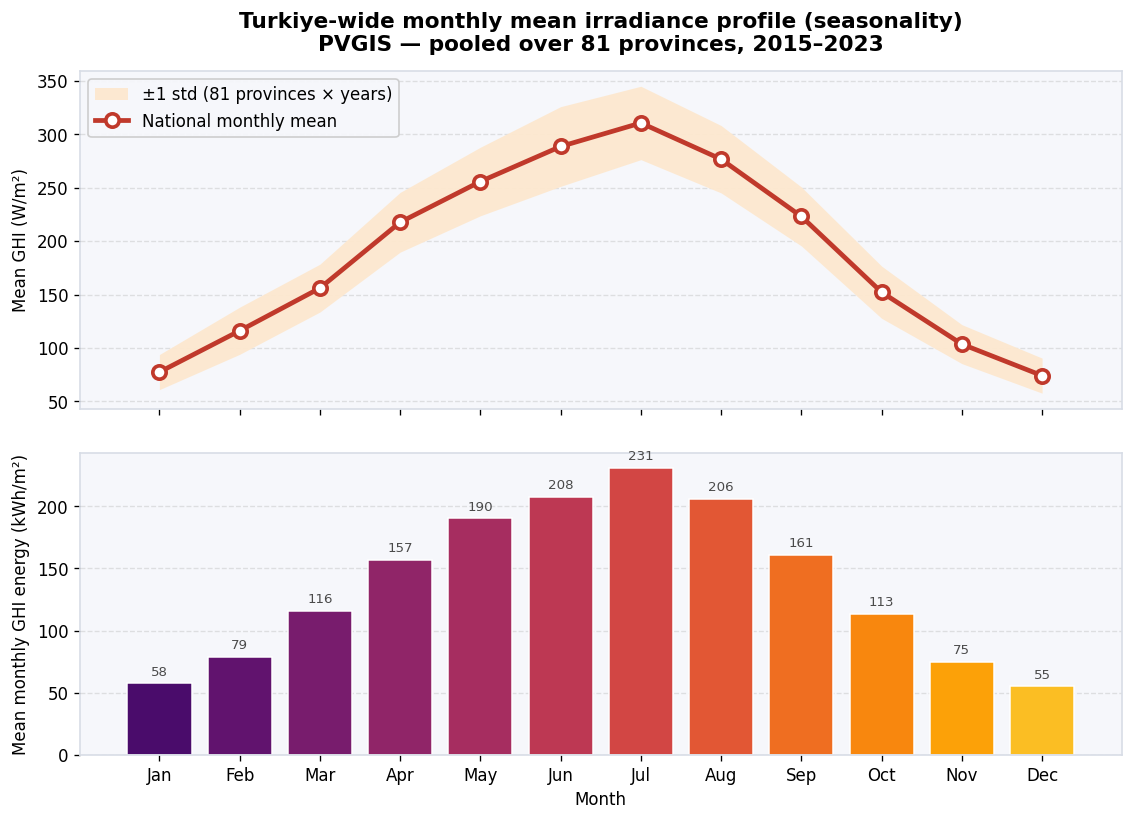

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    dm = df_monthly.copy()
except NameError:
    cwd = Path.cwd().resolve()
    root = next(
        (p for p in [cwd, *cwd.parents] if (p / "data" / "processed").exists()),
        None,
    )
    if root is None:
        raise RuntimeError(
            "df_monthly missing and project root not found. Run upstream cells or open notebook from repo."
        )
    fp = root / "data" / "processed" / "pvgis_turkey_81_provinces_monthly_2015_2023.csv"
    dm = pd.read_csv(fp, parse_dates=["date"])

prof = (
    dm.groupby("month", sort=True)
    .agg(
        mean_ghi=("avg_ghi_w_m2", "mean"),
        std_ghi=("avg_ghi_w_m2", "std"),
        mean_kwh=("monthly_ghi_kwh_m2", "mean"),
    )
    .reset_index()
)

assert len(prof) == 12

MONTH_ABBR = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
x = np.arange(12)

plt.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#f6f7fb",
        "axes.edgecolor": "#d8dde6",
        "axes.linewidth": 1.0,
        "axes.titleweight": "bold",
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
    }
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11.2, 7.4),
    sharex=True,
    dpi=120,
    gridspec_kw={"height_ratios": [1.12, 1.0], "hspace": 0.14},
)

ax0 = axes[0]
m = prof["mean_ghi"].to_numpy()
s = prof["std_ghi"].to_numpy()
ax0.fill_between(
    x,
    m - s,
    m + s,
    color="#fde8cf",
    linewidth=0,
    alpha=0.95,
    label="±1 std (81 provinces × years)",
)
ax0.plot(
    x,
    m,
    color="#c0392b",
    lw=2.85,
    marker="o",
    ms=8,
    mfc="white",
    mew=2.2,
    zorder=4,
    label="National monthly mean",
)
ax0.set_ylabel("Mean GHI (W/m²)")
ax0.set_title(
    "Turkiye-wide monthly mean irradiance profile (seasonality)\n"
    "PVGIS — pooled over 81 provinces, 2015–2023",
    fontsize=13,
    pad=12,
)
ax0.legend(loc="upper left", framealpha=0.96)
ax0.grid(True, axis="y")
ax0.set_axisbelow(True)

ax1 = axes[1]
colors = plt.cm.inferno(np.linspace(0.22, 0.85, 12))
bars = ax1.bar(x, prof["mean_kwh"], color=colors, edgecolor="white", linewidth=0.9)
ax1.set_ylabel("Mean monthly GHI energy (kWh/m²)")
ax1.set_xlabel("Month")
ax1.grid(True, axis="y")
ax1.set_axisbelow(True)

for rect, h in zip(bars, prof["mean_kwh"]):
    ax1.annotate(
        f"{h:.0f}",
        xy=(rect.get_x() + rect.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#4a4a4a",
    )

ax1.set_xticks(x)
ax1.set_xticklabels(MONTH_ABBR)

fig.align_ylabels(axes)
plt.tight_layout()
plt.show()

### Insights from the chart (seasonality)

> **Takeaway:** PVGIS monthly data here is a *pooled* average across 81 provinces and 2015–2023. That yields a single “national” profile; investment decisions still require drilling down to **province / site** level.

---

#### Power (top) vs energy (bottom) are not the same thing

- **Mean GHI (W/m²)** reflects roughly *instantaneous irradiance / power density*; **kWh/m²** is *integrated energy over the month* (scaled by hours in that month).
- The two panels therefore do not duplicate each other; together they clarify both **peak-season intensity** and **winter short-day effects**.

#### Strong seasonal amplitude

- In the top panel, the national mean profile sits near **~75 W/m²** in winter months and peaks above **~300 W/m²** in mid-summer — roughly a **four-fold** swing in *power density* across the year.
- In the bottom panel, comparing the **highest** typical monthly energy (on the order of **~231 kWh/m²**) with the **lowest** (**~55 kWh/m²**) shows an **~4×** “best month vs weakest month” gap on the energy side too. That underscores **material intra-year variation in capacity factor** (relevant for cash flow and financing stress tests).

#### Asymmetric ramps: spring accelerates, autumn falls fast

- From roughly February–May the curve tends to **rise steeply**; from August–November it tends to **fall steeply**.
- In operational terms, this supports a pattern where the **summer window is relatively short but intense**, while winter is **longer but low-output**.

#### The ±1σ band widens in summer

- The shaded band shows spread of GHI around the national mean across **province × year** draws. **Thicker bands in summer** suggest geographic disagreement is more pronounced when irradiance is high (south vs coast vs inland vs elevation, etc.).
- **Investment lesson:** The national mean is a useful *summary*; for **single-location** decisions that dispersion can either inflate **wrong-site** risk or hide **high-potential** pockets.

#### June–August: the high-energy core of the year

- Bar heights show the **summer trio** carries a large share of annual energy. That raises practical themes such as:
  - **Seasonally concentrated cash generation**
  - **Maintenance / outage planning** being critical in summer months
  - Potentially **storage or commercial structuring** where relevant

---

*Closing note:* This figure illustrates **national-average seasonality**; the next step in feasibility or modelling is to **disaggregate** by your target province or site (and validate with PVGIS or on-site data where appropriate).
